### [Essential Tools for Time Series Forecasting](https://medium.com/code-applied/essential-tools-for-time-series-forecasting-a759d676a219)

> Time series forecasting is a critical aspect of data science, enabling us to predict future values based on historical data.

In [1]:
!pip install -q statsforecast fpppy utilsforecast

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

# Let's load some data
# We are using the Australian Production dataset provided in the reference
au_prod_data = '/content/aus_production.csv'
production_df = pd.read_csv(au_prod_data, parse_dates=["ds"])

# Formatting dataset : cols == [ds, unique_id, y]
df = production_df.melt(
    id_vars='ds',
    value_vars=production_df.columns[1:],
    var_name='unique_id',
    value_name='y'
)
df.head()

,ds,unique_id,y
0,1956-01-01,Beer,284.0
1,1956-04-01,Beer,213.0
2,1956-07-01,Beer,227.0
3,1956-10-01,Beer,308.0
4,1957-01-01,Beer,262.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         1308 non-null   datetime64[ns]
 1   unique_id  1308 non-null   object        
 2   y          1264 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 30.8+ KB


In [5]:
df.describe()

,ds,y
count,1308,1264.000000
mean,1983-02-15 00:13:12.660550464,6463.185918
min,1956-01-01 00:00:00,5.000000
25%,1969-07-01 00:00:00,354.500000
50%,1983-02-15 00:00:00,574.500000
75%,1996-10-01 00:00:00,6152.500000
max,2010-04-01 00:00:00,64067.000000
std,NaN,12983.317887


<Axes: title={'center': 'Aus Beer Production 1960-2010'}, xlabel='ds'>

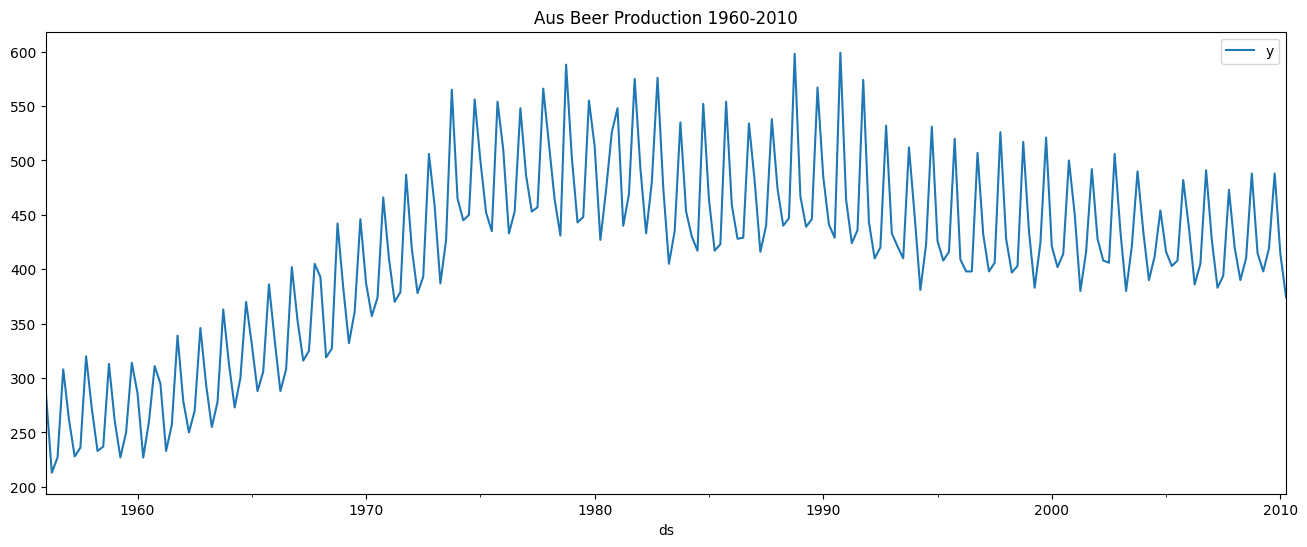

In [6]:
df.query('unique_id == "Beer"').plot(x="ds", y="y",
                                     figsize=(16, 6),
                                     title= 'Aus Beer Production 1960-2010')

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import SklearnModel
from statsforecast.utils import ConformalIntervals
from statsforecast.models import (
    WindowAverage,
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    HistoricAverage)


# Train set
beers_df = df.query("unique_id == 'Beer' and ds >= '1992-01-01'")
train = beers_df[:-14]
test = beers_df[-14:]

# Models chosen
avg_method = HistoricAverage()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(4)

# Train the model
sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method],
    freq=pd.offsets.QuarterBegin(1)
)
sf.fit(train)

StatsForecast(models=[HistoricAverage,Naive,SeasonalNaive])

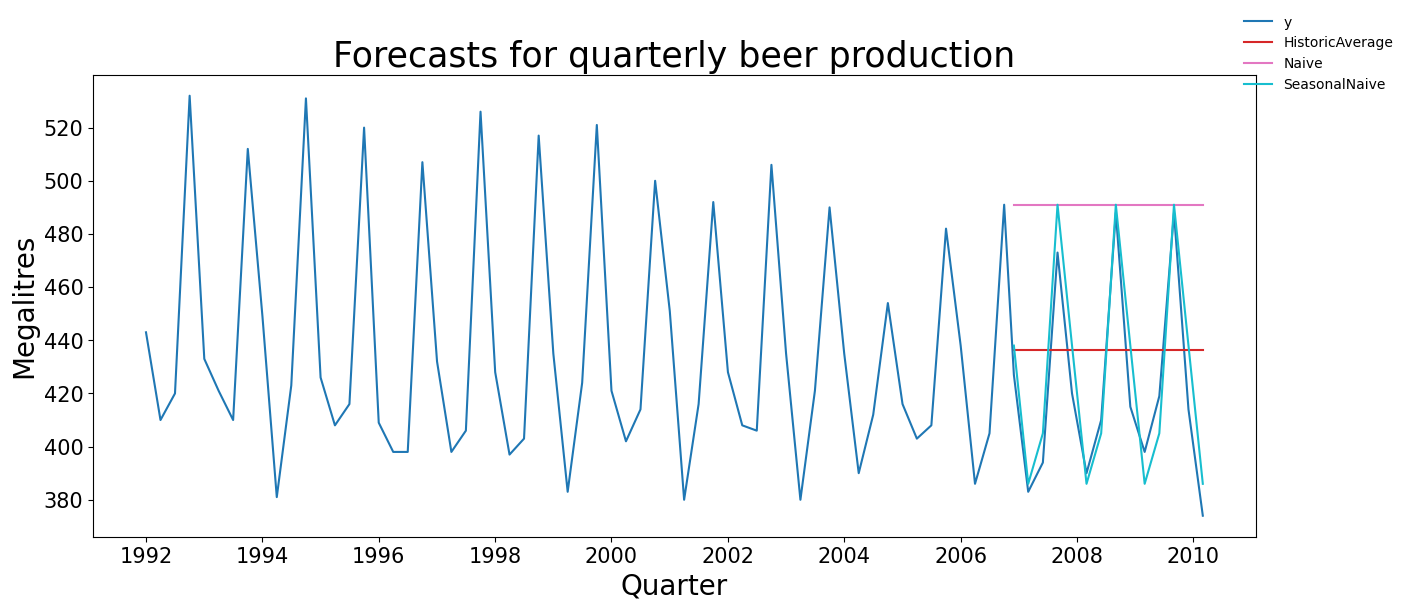

In [8]:
from fpppy.utils import plot_series

# View the predictions with a horizon of 14 periods ahead
fcasts = sf.predict(h=14)
fcasts["y"] = test["y"].values

plot_series(train, fcasts,
            xlabel="Quarter",
            ylabel="Megalitres",
            title="Forecasts for quarterly beer production",
            rm_legend=False)

In [9]:
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
train["fitted"] = fitted_values["HistoricAverage"].values
train["resid"] = train["y"] - train["fitted"]

##### Residual Diagnostics

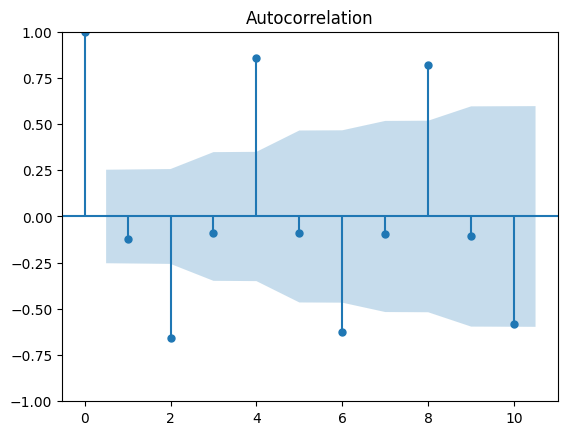

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(train.resid, lags=10)
plt.show()

In [11]:
# mean must have zero mean
train.resid.mean()

np.float64(1.1368683772161604e-14)

In [12]:
from scipy.stats import shapiro
shapiro(train.resid)

ShapiroResult(statistic=np.float64(0.8661783811461596), pvalue=np.float64(9.464662131980603e-06))

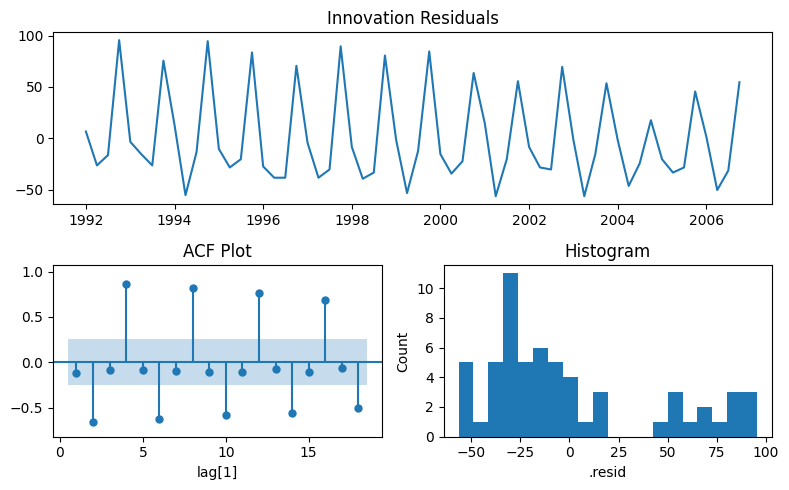

In [13]:
def plot_diagnostics(data):
    fig = plt.figure(figsize=(8, 5))

    ax1 = fig.add_subplot(2, 2, (1, 2))
    ax1.plot(data['ds'], data["resid"])
    ax1.set_title("Innovation Residuals")

    ax2 = fig.add_subplot(2, 2, 3)
    plot_acf(data["resid"].dropna(), ax=ax2, zero=False,
      bartlett_confint=False, auto_ylims=True)
    ax2.set_title("ACF Plot")
    ax2.set_xlabel('lag[1]')

    ax3 = fig.add_subplot(2, 2, 4)
    ax3.hist(data["resid"], bins=20)
    ax3.set_title("Histogram")
    ax3.set_xlabel(".resid")
    ax3.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


plot_diagnostics(train)

##### Distributional Forecasts and Prediction Intervals

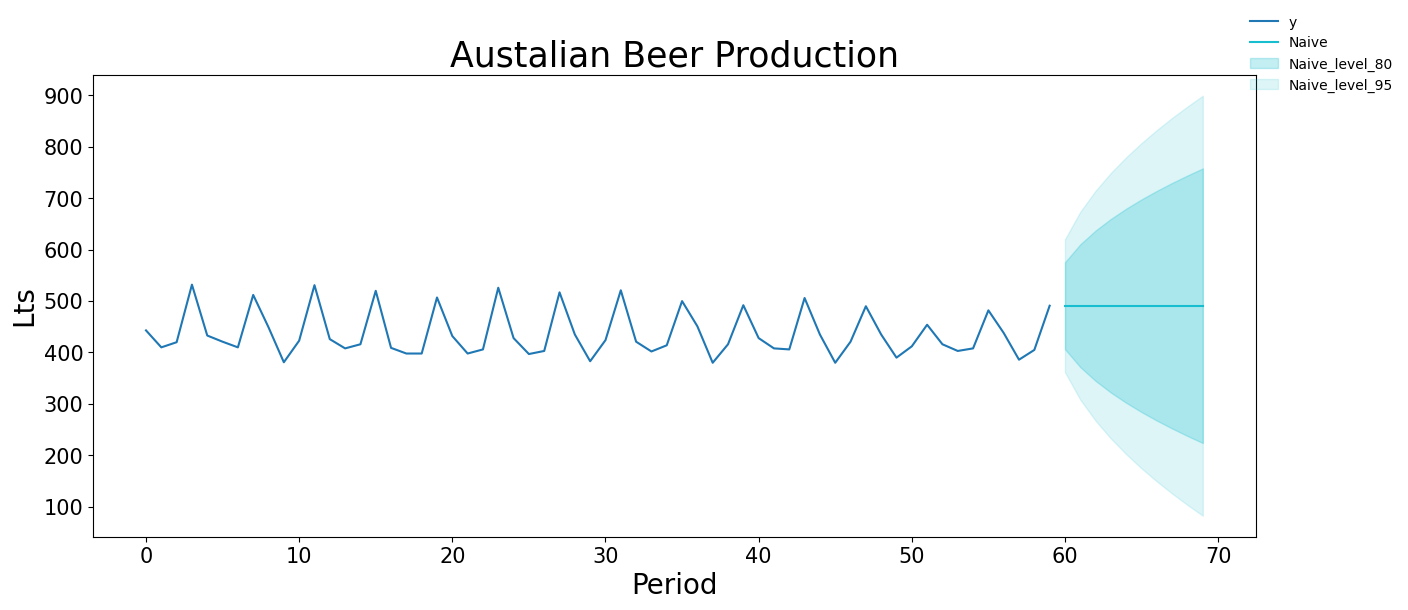

In [14]:
import numpy as np

# Forecasting 10 periods with 80% and 95% Confidence
sf = StatsForecast(models=[naive_method], freq="Q")
fcasts = sf.forecast(df=train, h=10, level=[80, 95])

# Plot
train["ds"] = np.arange(len(train))
fcasts["ds"] = train["ds"].max() + np.arange(start=1, stop=len(fcasts) + 1)
plot_series(train, fcasts, level=[80, 95],
            xlabel="Period",
            ylabel="Lts",
            title="Austalian Beer Production",
            rm_legend=False)

##### Evaluating Point Forecast Accuracy

- **Scale-Dependent Errors:** _MAE_ and _RMSE_.
- **Percentage Errors:** _MAPE_ and _sMAPE_.
- **Scaled Errors:** _MASE_ and _RMSSE_.

In [15]:
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape, mase

from functools import partial

# Re-create train and test to ensure 'ds' column is datetime
beers_df = df.query("unique_id == 'Beer' and ds >= '1992-01-01'")
train = beers_df[:-14]
test = beers_df[-14:]

sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method],
    freq=pd.offsets.QuarterBegin(1)
)
sf.fit(train)

fcasts = sf.predict(h=14)
fcasts["y"] = test["y"].values

sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
train["fitted"] = fitted_values["HistoricAverage"].values
train["resid"] = train["y"] - train["fitted"]
train["innov"] = train["y"] - train["fitted"]

# Evaluation
evaluation = evaluate(fcasts, metrics=[rmse, mae, mape, partial(mase, seasonality=4)], train_df=train)
evaluation

,unique_id,metric,HistoricAverage,Naive,SeasonalNaive
0,Beer,rmse,38.889711,78.622516,13.488090
1,Beer,mae,35.471429,70.071429,11.500000
2,Beer,mape,0.085136,0.174390,0.027587
3,Beer,mase,2.437301,4.814724,0.790184


##### Time Series Cross-Validation
Time series cross-validation involves a series of test sets, each consisting of a single observation, with corresponding training sets comprising only prior observations.

In [16]:
# Cross validation
seasonal_naive_method = SeasonalNaive(4)

sf = StatsForecast(models=[seasonal_naive_method], freq="Q")
cv_df = sf.cross_validation(h=3, df=train, step_size=1, test_size=10)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive
0,Beer,2004-07-01,2004-04-01,412.0,421.0
1,Beer,2004-10-01,2004-04-01,454.0,490.0
2,Beer,2005-01-01,2004-04-01,416.0,435.0
3,Beer,2004-10-01,2004-07-01,454.0,490.0
4,Beer,2005-01-01,2004-07-01,416.0,435.0
